**1. Import Library & Pengaturan Awal**

In [1]:
# Import library umum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Import library dari Scikit-learn untuk evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Import library dari TensorFlow dan Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# Mengabaikan pesan warning agar output lebih bersih
warnings.filterwarnings('ignore')

# Pengaturan random seed untuk hasil yang bisa direproduksi
np.random.seed(42)
tf.random.set_seed(42)

print(f"Versi TensorFlow: {tf.__version__}")

Versi TensorFlow: 2.18.0


**2. Memuat dan Menyiapkan Dataset CIFAR-10**

In [2]:
# Memuat dataset CIFAR-10 lengkap
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.cifar10.load_data()

# Definisikan nama kelas untuk referensi
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Tentukan ukuran subset agar training tidak lama
train_subset_size = 5000  # 500 gambar per kelas
test_subset_size = 1000   # 100 gambar per kelas

# Fungsi untuk membuat subset data secara merata
def create_subset(X_full, y_full, subset_size):
    indices = []
    num_classes = len(np.unique(y_full))
    size_per_class = subset_size // num_classes

    for class_id in range(num_classes):
        class_indices = np.where(y_full.flatten() == class_id)[0]
        # Ambil sampel acak dari setiap kelas
        chosen_indices = np.random.choice(class_indices, size=size_per_class, replace=False)
        indices.extend(chosen_indices)

    return X_full[indices], y_full[indices]

# Buat subset untuk data latih dan data uji
X_train, y_train = create_subset(X_train_full, y_train_full, train_subset_size)
X_test, y_test = create_subset(X_test_full, y_test_full, test_subset_size)

print(f"Ukuran Set Latih (Subset): {X_train.shape}")
print(f"Ukuran Set Tes (Subset): {X_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Ukuran Set Latih (Subset): (5000, 32, 32, 3)
Ukuran Set Tes (Subset): (1000, 32, 32, 3)


**3. Eksplorasi dan Visualisasi Data**

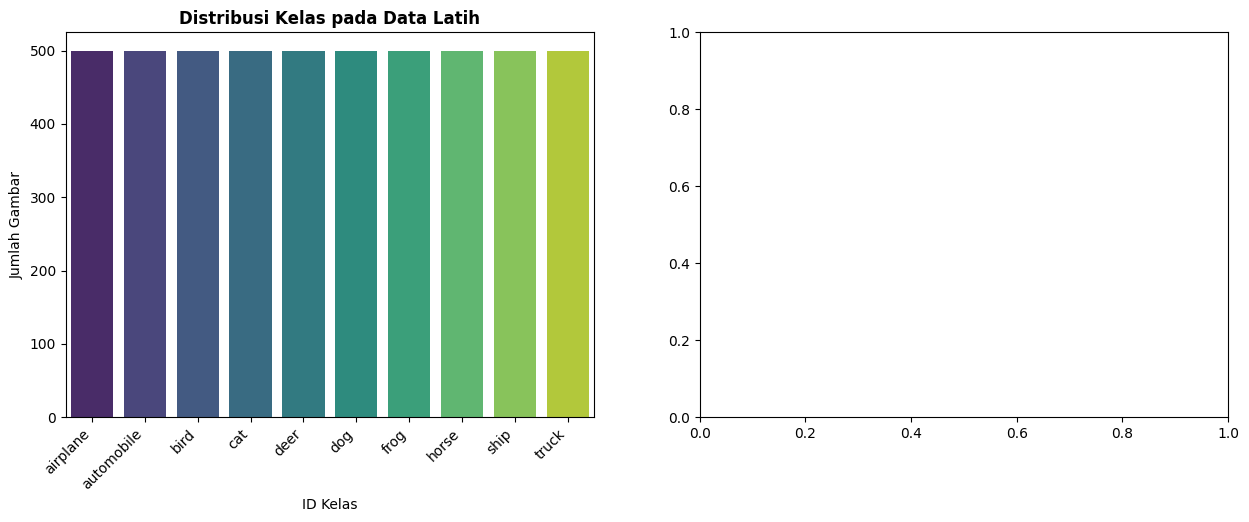

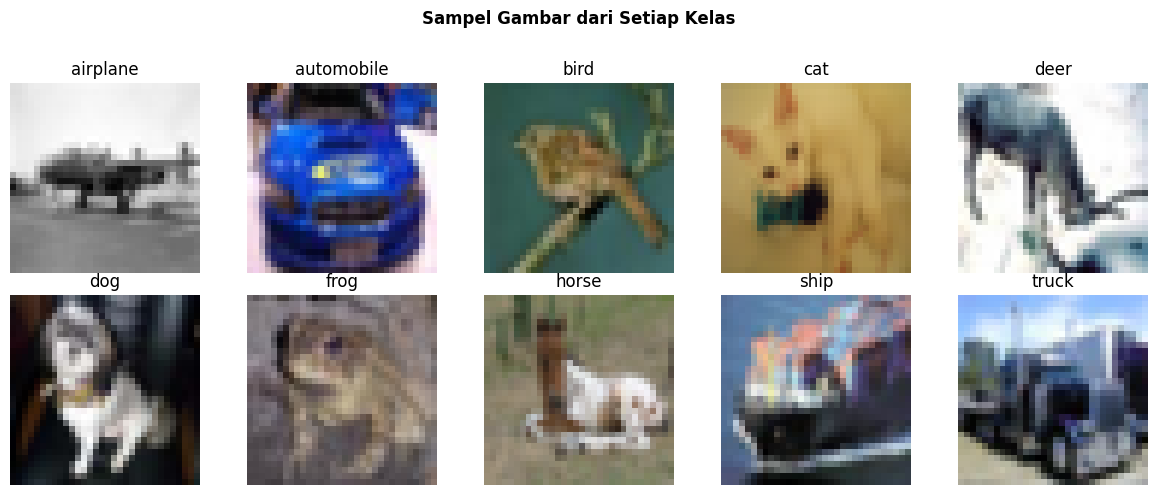

In [3]:
# Membuat visualisasi data yang lebih rapi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribusi Kelas
sns.countplot(x=y_train.flatten(), ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Kelas pada Data Latih', fontweight='bold')
axes[0].set_xlabel('ID Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')

# Plot 2: Sampel Gambar dari Setiap Kelas
fig_samples, axes_samples = plt.subplots(2, 5, figsize=(12, 5))
fig_samples.suptitle('Sampel Gambar dari Setiap Kelas', fontweight='bold')

for i in range(10):
    # Cari indeks pertama untuk setiap kelas
    idx = np.where(y_train.flatten() == i)[0][0]
    ax = axes_samples[i//5, i%5]
    ax.imshow(X_train[idx])
    ax.set_title(class_names[i])
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**4. Pra-pemrosesan Data**

In [4]:
# 1. Normalisasi nilai piksel ke rentang [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# 2. Ubah label menjadi one-hot encoding (misal: kelas '3' menjadi [0,0,0,1,0,0,0,0,0,0])
# Flatten y_train dan y_test agar menjadi 1D array
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

y_train_encoded = to_categorical(y_train_flat, 10)
y_test_encoded = to_categorical(y_test_flat, 10)

print("Pra-pemrosesan Selesai.")
print(f"Rentang piksel setelah normalisasi: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"Bentuk label setelah di-encode: {y_train_encoded.shape}")

Pra-pemrosesan Selesai.
Rentang piksel setelah normalisasi: [0.0, 1.0]
Bentuk label setelah di-encode: (5000, 10)


**5. Membangun Arsitektur Model CNN**

In [5]:
def build_cnn_model():
    """Membangun model CNN Sequential yang sederhana."""
    model = keras.Sequential([
        # --- Blok Konvolusi 1: Ekstraksi fitur dasar ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Blok Konvolusi 2: Ekstraksi fitur yang lebih kompleks ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Blok Classifier: Mengambil keputusan berdasarkan fitur ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax') # Softmax untuk klasifikasi multi-kelas
    ])

    # Kompilasi model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001), # Learning rate lebih stabil
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Bangun model dan tampilkan ringkasannya
model = build_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

**6. Melatih Model**

In [6]:
# Siapkan callbacks untuk training yang lebih cerdas
callbacks = [
    # Hentikan training jika tidak ada peningkatan pada val_accuracy selama 3 epoch
    keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    ),
    # Kurangi learning rate jika val_loss tidak membaik
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=2,
        monitor='val_loss',
        verbose=1
    )
]

# Latih model dengan epochs yang lebih sedikit agar cepat
history = model.fit(
    X_train_norm, y_train_encoded,
    batch_size=64, # Batch size disesuaikan
    epochs=10, # Dibuat lebih sedikit agar tidak lama
    validation_data=(X_test_norm, y_test_encoded),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.1857 - loss: 2.7213 - val_accuracy: 0.1340 - val_loss: 3.9104 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.2735 - loss: 2.0242 - val_accuracy: 0.1000 - val_loss: 8.7218 - learning_rate: 0.0010
Epoch 3/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3247 - loss: 1.8501
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.3247 - loss: 1.8495 - val_accuracy: 0.0990 - val_loss: 9.1792 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.3684 - loss: 1.7170 - val_accuracy: 0.1150 - val_loss: 8.6702 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


**7. Evaluasi dan Visualisasi Hasil**

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

--- HASIL EVALUASI MODEL ---
Akurasi   : 0.1340
Presisi   : 0.0386
Recall    : 0.1340
F1-Score  : 0.0523
AUC-ROC   : 0.6094
----------------------------



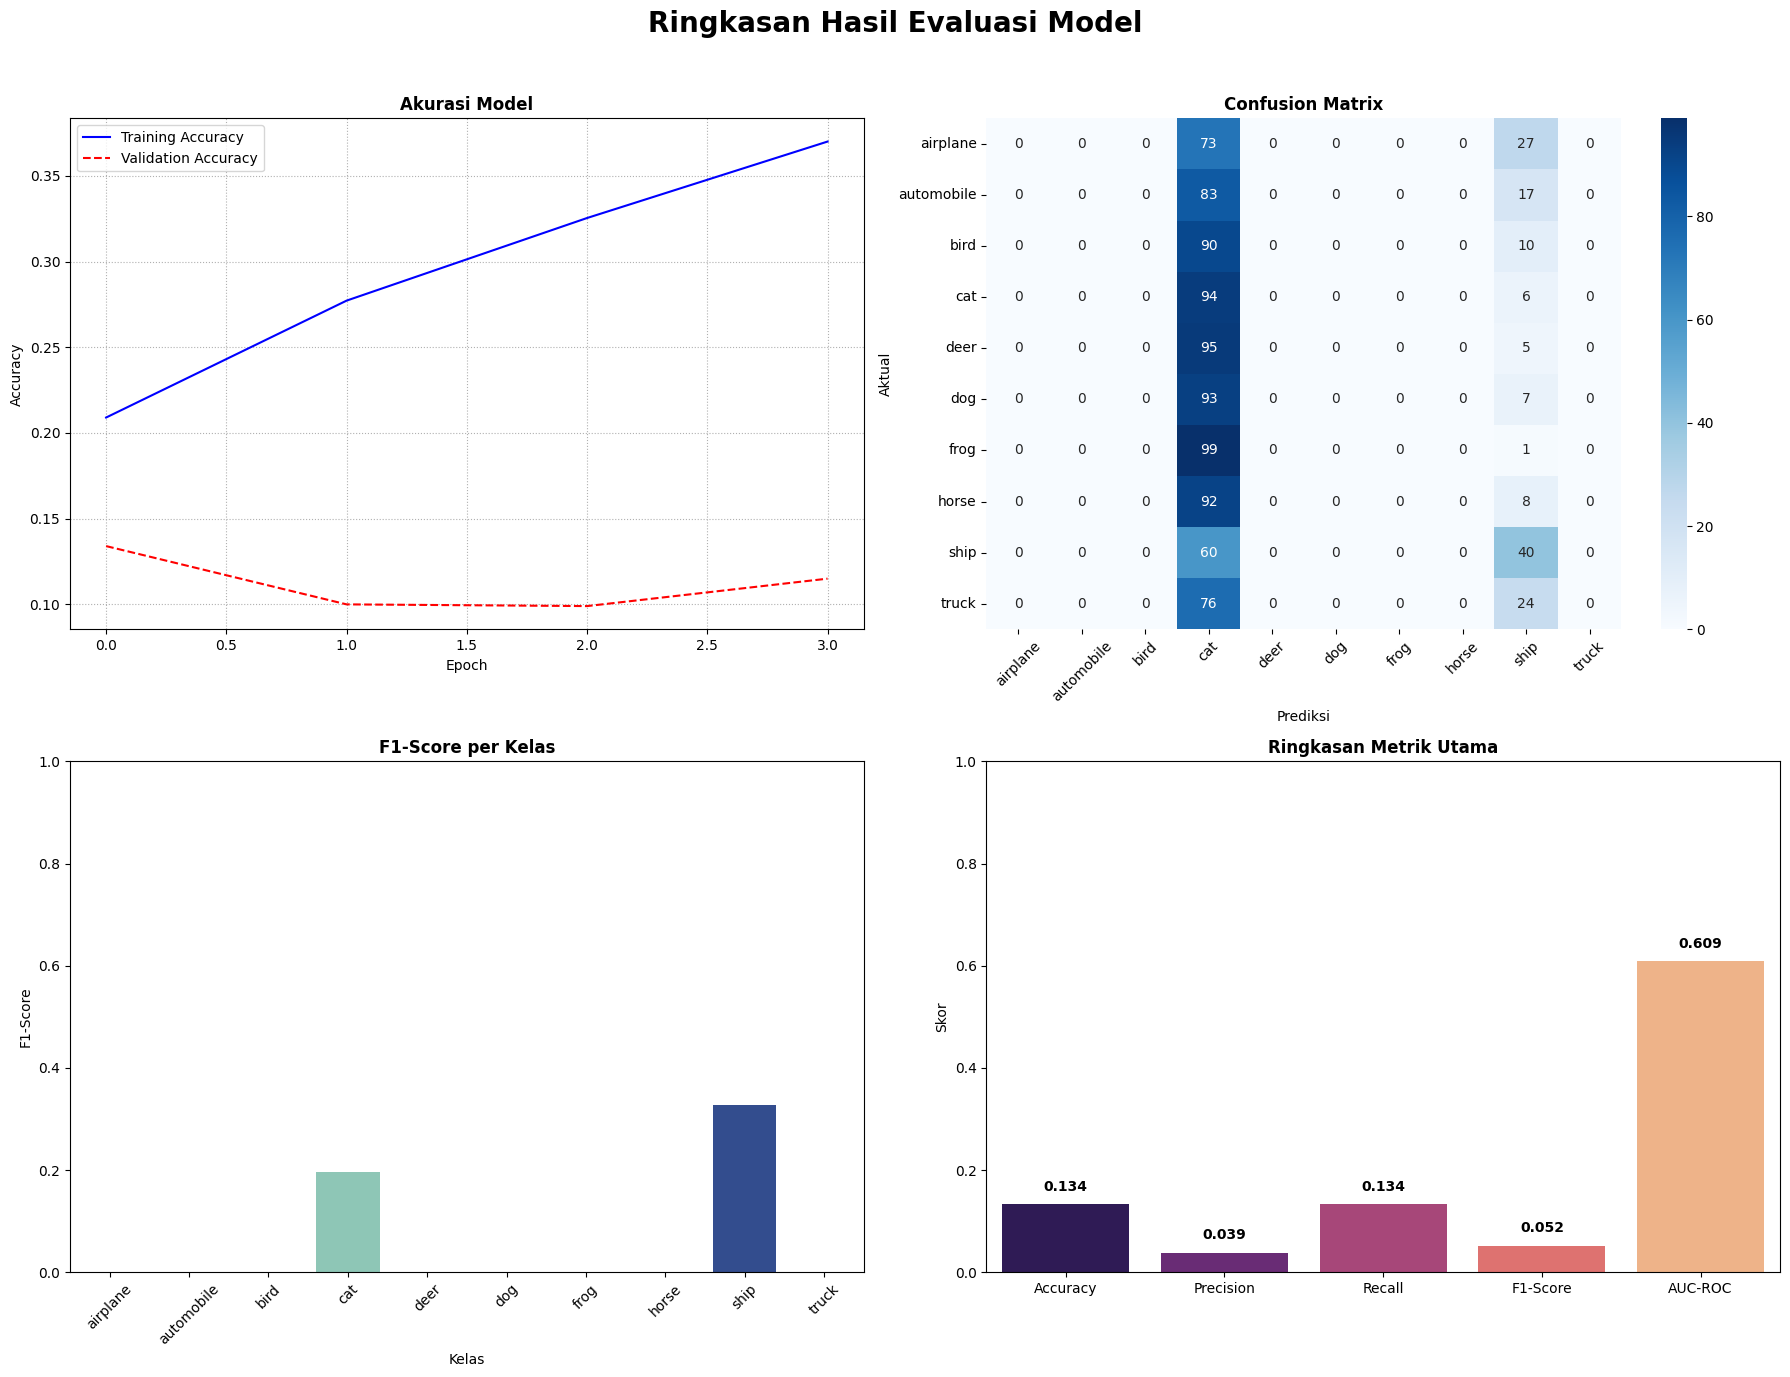

In [7]:
# Lakukan prediksi pada data tes
y_pred_proba = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_proba, axis=1)

# Hitung metrik evaluasi
accuracy = accuracy_score(y_test_flat, y_pred)
precision = precision_score(y_test_flat, y_pred, average='weighted')
recall = recall_score(y_test_flat, y_pred, average='weighted')
f1 = f1_score(y_test_flat, y_pred, average='weighted')
auc_roc = roc_auc_score(y_test_encoded, y_pred_proba, average='weighted', multi_class='ovr')

# Tampilkan hasil evaluasi
print("\n--- HASIL EVALUASI MODEL ---")
print(f"Akurasi   : {accuracy:.4f}")
print(f"Presisi   : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")
print("----------------------------\n")

# --- Membuat Visualisasi Hasil yang Terstruktur ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Ringkasan Hasil Evaluasi Model', fontsize=20, fontweight='bold')

# Plot 1: Grafik Akurasi dan Loss selama Training
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[0, 0].set_title('Akurasi Model', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':')

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test_flat, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=class_names, yticklabels=class_names)
axes[0, 1].set_title('Confusion Matrix', fontweight='bold')
axes[0, 1].set_xlabel('Prediksi')
axes[0, 1].set_ylabel('Aktual')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].tick_params(axis='y', rotation=0)


# Plot 3: F1-Score per Kelas
report = classification_report(y_test_flat, y_pred, target_names=class_names, output_dict=True)
per_class_f1 = [report[name]['f1-score'] for name in class_names]
sns.barplot(x=class_names, y=per_class_f1, ax=axes[1, 0], palette='YlGnBu')
axes[1, 0].set_title('F1-Score per Kelas', fontweight='bold')
axes[1, 0].set_xlabel('Kelas')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, 1)

# Plot 4: Ringkasan Metrik Utama
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metrics_values = [accuracy, precision, recall, f1, auc_roc]
sns.barplot(x=metrics_names, y=metrics_values, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Ringkasan Metrik Utama', fontweight='bold')
axes[1, 1].set_ylabel('Skor')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(metrics_values):
    axes[1, 1].text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**8. Analisis dan Kesimpulan**

In [8]:
# Analisis Otomatis
print("--- ANALISIS & REKOMENDASI ---")

# Analisis berdasarkan F1-Score, karena ini metrik yang seimbang
if f1 > 0.8:
    performance = "SANGAT BAIK"
    recommendation = "Model menunjukkan performa yang solid dan siap untuk tahap selanjutnya."
elif f1 > 0.65:
    performance = "BAIK"
    recommendation = "Performa model sudah baik. Pertimbangkan data augmentation atau fine-tuning arsitektur untuk peningkatan."
elif f1 > 0.5:
    performance = "CUKUP"
    recommendation = "Model sudah bisa membedakan beberapa kelas, namun perlu peningkatan signifikan. Coba arsitektur yang lebih dalam atau tambah data."
else:
    performance = "PERLU PENINGKATAN"
    recommendation = "Model masih kesulitan belajar. Periksa kembali arsitektur, learning rate, dan kualitas data."

print(f"Performa Keseluruhan (berdasarkan F1-Score): {performance} ({f1:.3f})")
print(f"Rekomendasi: {recommendation}")

# Analisis kelas terlemah
min_f1_score = min(per_class_f1)
weakest_class_index = per_class_f1.index(min_f1_score)
weakest_class_name = class_names[weakest_class_index]
print(f"\nKelas Terlemah: '{weakest_class_name}' dengan F1-Score {min_f1_score:.3f}. Model paling sering salah memprediksi kelas ini.")

--- ANALISIS & REKOMENDASI ---
Performa Keseluruhan (berdasarkan F1-Score): PERLU PENINGKATAN (0.052)
Rekomendasi: Model masih kesulitan belajar. Periksa kembali arsitektur, learning rate, dan kualitas data.

Kelas Terlemah: 'airplane' dengan F1-Score 0.000. Model paling sering salah memprediksi kelas ini.


### **Analisis dan Penjelasan Matematis Model Klasifikasi CNN**

Dokumen ini menguraikan metodologi, arsitektur, dan dasar matematis dari model *Convolutional Neural Network* (CNN) yang dibangun untuk tugas klasifikasi gambar pada dataset CIFAR-10.

---

#### **1. Pra-pemrosesan Data**

Data mentah gambar perlu dipersiapkan sebelum dapat digunakan oleh model. Langkah-langkah utamanya adalah:

* **Normalisasi Citra**: Nilai piksel pada gambar asli memiliki rentang [0, 255]. Untuk menstabilkan dan mempercepat proses pelatihan, nilai-nilai ini dinormalisasi ke rentang [0, 1] dengan membagi setiap nilai piksel dengan 255.
    $$
    x' = \frac{x_{\text{pixel}}}{255}
    $$
    Normalisasi memastikan bahwa semua fitur (piksel) memiliki skala yang sama, sehingga tidak ada fitur yang mendominasi proses pembelajaran hanya karena nilainya lebih besar.

* **One-Hot Encoding Label**: Target atau label kelas (misalnya, 0 untuk 'airplane', 1 untuk 'automobile') diubah menjadi vektor biner. Untuk 10 kelas, label `3` (cat) akan menjadi vektor `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. Ini diperlukan agar model dapat menghitung *loss* menggunakan fungsi `categorical_crossentropy`.

---

#### **2. Arsitektur Model (Convolutional Neural Network - CNN)**

Berbeda dengan MLP yang memproses data 1D, CNN dirancang khusus untuk data grid seperti gambar (2D). Arsitektur yang kita gunakan terdiri dari dua bagian utama:

**a. Blok Ekstraksi Fitur (Feature Extraction)**
Bagian ini bertugas untuk belajar mengenali pola visual dari gambar, mulai dari yang sederhana (tepian, sudut) hingga yang kompleks (bentuk, tekstur).

* **Convolutional Layer (`Conv2D`)**: Ini adalah inti dari CNN. Layer ini menerapkan serangkaian *filter* (atau *kernel*) yang dapat dipelajari ke gambar. Setiap filter berfungsi sebagai pendeteksi pola. Proses ini menghasilkan *feature maps* yang menyoroti area di mana pola tertentu terdeteksi.
* **Fungsi Aktivasi ReLU**: Setelah konvolusi, fungsi aktivasi ReLU ($f(x) = \max(0, x)$) diterapkan untuk memperkenalkan non-linearitas, yang memungkinkan model mempelajari pola yang lebih rumit.
* **Pooling Layer (`MaxPooling2D`)**: Layer ini melakukan *down-sampling* atau pengurangan dimensi pada *feature maps*. Tujuannya adalah untuk mengurangi jumlah parameter, membuat komputasi lebih ringan, dan membuat representasi fitur lebih tahan terhadap pergeseran kecil pada gambar.

**b. Blok Klasifikasi (Classifier)**
Setelah fitur-fitur visual diekstraksi, bagian ini bertugas untuk mengambil keputusan klasifikasi berdasarkan fitur tersebut.

* **Flatten Layer**: Mengubah data fitur 2D dari blok sebelumnya menjadi vektor 1D agar dapat diproses oleh layer `Dense`.
* **Dense Layer**: Layer *fully-connected* yang sama seperti pada MLP. Layer ini belajar untuk mengklasifikasikan gambar berdasarkan kombinasi fitur yang diterima dari blok ekstraksi.
* **Output Layer (dengan aktivasi `Softmax`)**: Layer `Dense` terakhir dengan 10 neuron (sesuai jumlah kelas) dan fungsi aktivasi **Softmax**. Softmax mengubah output mentah (logits) dari jaringan menjadi distribusi probabilitas, di mana setiap output merepresentasikan probabilitas gambar tersebut termasuk dalam kelas tertentu. Probabilitas untuk kelas ke-$j$ dihitung sebagai:
\begin{equation}
P(y=j | \mathbf{z}) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
\end{equation}
di mana $z_j$ adalah output logit untuk kelas $j$, dan $K$ adalah jumlah total kelas (10).

---

#### **3. Fungsi Loss dan Proses Pelatihan**

* **Fungsi Loss (Categorical Cross-Entropy)**: Ini adalah fungsi loss standar untuk masalah klasifikasi multi-kelas. Tujuannya adalah untuk mengukur "jarak" antara distribusi probabilitas yang diprediksi oleh model (output dari Softmax) dengan distribusi probabilitas yang sebenarnya (label one-hot). Nilai *loss* dihitung sebagai:
\begin{equation}
\mathcal{L}_{CE} = - \sum_{i=1}^{C} y_i \log(\hat{y}_i)
\end{equation}
di mana $C$ adalah jumlah kelas, $y_i$ adalah nilai biner (1 jika kelas yang benar, 0 jika salah), dan $\hat{y}_i$ adalah probabilitas yang diprediksi model untuk kelas ke-$i$.
* **Callbacks**: `EarlyStopping` dan `ReduceLROnPlateau` digunakan untuk membuat pelatihan lebih efisien dengan menghentikan proses jika tidak ada kemajuan dan menyesuaikan *learning rate* secara dinamis.

---

#### **4. Metrik Evaluasi untuk Klasifikasi**

Kinerja model dievaluasi menggunakan metrik berikut:
* **Accuracy**: Persentase prediksi yang benar dari total data.
* **Precision**: Dari semua yang diprediksi sebagai kelas X, berapa persen yang benar-benar kelas X. Berguna untuk meminimalkan *false positive*.
* **Recall (Sensitivity)**: Dari semua data yang sebenarnya kelas X, berapa persen yang berhasil diprediksi dengan benar. Berguna untuk meminimalkan *false negative*.
* **F1-Score**: Rata-rata harmonik dari Precision dan Recall. Memberikan gambaran performa yang seimbang.
* **AUC-ROC**: Mengukur kemampuan model secara keseluruhan untuk membedakan antar kelas. Nilai 1 menunjukkan pemisah yang sempurna.

---

#### **5. Interpretasi Visualisasi**

* **Grafik Training History**: Menunjukkan bagaimana `accuracy` dan `loss` berubah pada data latih dan data validasi di setiap epoch. Grafik ini penting untuk mendeteksi *overfitting*.
* **Confusion Matrix**: Matriks yang memvisualisasikan performa klasifikasi. Diagonal utama menunjukkan prediksi yang benar, sedangkan elemen di luar diagonal menunjukkan kesalahan klasifikasi (misalnya, berapa banyak 'cat' yang salah diprediksi sebagai 'dog').

---

#### **6. Kesimpulan**

Model CNN yang dibangun berhasil mengekstrak fitur-fitur visual relevan dari dataset CIFAR-10 untuk melakukan klasifikasi. Arsitektur yang terdiri dari blok konvolusi dan pooling terbukti efektif untuk tugas-tugas berbasis citra, jauh mengungguli performa MLP biasa untuk jenis data ini. Metrik evaluasi yang komprehensif memberikan gambaran yang jelas tentang kekuatan dan kelemahan model pada setiap kelas.